# **Arabic Sentiment ML Project**

## **Import Libraries**

In [1]:
# Data handling & visualization
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

# ML models & metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Sparse matrix operations
from scipy.sparse import hstack

from sentence_transformers import SentenceTransformer

# Misc
import string

C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Global Variables**

In [2]:
# Labels
LABELS = {"POS", "NEG", "OBJ", "NEUTRAL"}

# Arabic stopwords
nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))
negations = {"مش", "مو", "ما", "ليس", "لا", "لم", "لن", "بدون", "غير"}
arabic_stopwords -= negations

# Stemmer
stemmer = ISRIStemmer()

# Emoji dictionary
EMO_POS = " EMO_POS "
EMO_NEG = " EMO_NEG "
EMO_NEU = " EMO_NEU "

POS_EMOJIS = {
    "😂", "🤣", "😄", "😃", "😊", "😁", "😍", "🥰",
    "❤️", "💖", "💕", "👍", "👏", "🔥"
}

NEG_EMOJIS = {
    "😡", "🤬", "😠", "😢", "😭", "💔",
    "👎", "😞", "😤", "😰", "😨"
}

NEU_EMOJIS = {
    "😐", "😑", "😶", "🙄"
}

# Arabic punctuation
ARABIC_PUNCTUATION = "؟،؛ـ"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\batol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Dataset Loading & Conversion**

In [3]:
# Load TXT dataset and convert to CSV
def convert_to_csv(file_name="Arabic-Tweets_Dataset.txt"):
    data = []
    with open(file_name, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit("\t", 1)
            if len(parts) == 2 and parts[1] in LABELS:
                text, label = parts
                data.append([text, label])
            else:
                print("Skipped malformed line:", line)
    df = pd.DataFrame(data, columns=["text", "label"])
    df["label"] = df["label"].replace({"NEUTRAL": "OBJ"})
    df.to_csv("Arabic-Tweets_Dataset.csv", index=False, encoding="utf-8-sig")
    return df

df = convert_to_csv()
df.head()

,text,label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ


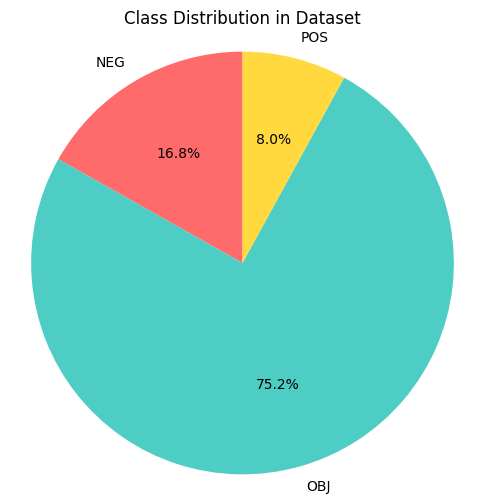

In [4]:
y = df["label"]

# Count number of samples per class
counts = y.value_counts()[["NEG", "OBJ", "POS"]]

plt.figure(figsize=(6,6))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#FF6B6B','#4ECDC4','#FFD93D']
)
plt.title("Class Distribution in Dataset")
plt.axis('equal')  # Makes the pie circular
plt.show()


## **1. Preprocessing**
We start by converting the raw TXT dataset into CSV for easier handling. 
We then normalize Arabic text to reduce variations in letters (e.g., "أ" → "ا") and remove elongations (like "مررررحبا" → "مرحبا"). 
Emojis are replaced with tokens representing sentiment, and negation words are prefixed with "NOT_" to capture their effect in sentiment analysis.

### **1.1 Normalize Arabic Letters**

In [5]:
# Arabic text normalization
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    return text

### **1.2 Remove Elongation**

In [6]:
def remove_elongation(text):
    return re.sub(r'(.)\1+', r'\1', text)

### **1.3 Replace Emojis**

In [7]:
def replace_emojis(text):
    result = []
    for ch in text:
        if ch in POS_EMOJIS:
            result.append(EMO_POS)
        elif ch in NEG_EMOJIS:
            result.append(EMO_NEG)
        elif ch in NEU_EMOJIS:
            result.append(EMO_NEU)
        else:
            result.append(ch)
    return "".join(result)

### **1.4 Handle Negation**

In [8]:
def handle_negation(text):
    tokens = text.split()
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations and i+1 < len(tokens):
            result.append("NOT_" + tokens[i+1])
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return " ".join(result)

### **1.5 Remove Stopwords**

In [9]:
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    return " ".join(words)

### **1.7 Stemming**

In [10]:
def stem_text(text):
    words = text.split()
    return " ".join([stemmer.stem(w) for w in words])

### **1.6 Apply Preprocessing**

In [11]:
def preprocess_text(text):
    text = normalize_arabic(text)
    text = remove_elongation(text)
    text = replace_emojis(text)
    text = handle_negation(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)
df.head()

,text,label,cleaned_text
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ,قال ريس #المحكمه_الدستوريه تظر قال #ريس_القضاء...
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS,اهن دكتور حمد جمل دين، قيد حزب صر، نسب صدر اول...
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG,ردع سقو بمر مرهاخر رسل عصم عري الي شنط شي قرف
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ,#الحريه_والعداله | شهد ان: #ليله_الاتحاديه اول...
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ,ولد اقل خطر حشش تضح اقل مل اله وكل تعط حضر فسق...


## **2. Feature Extraction**
We extract both:
1. **Text-based features** using TF(Term Frequency inside one tweet)-IDF(Inverse Document Frequency meaning in the whole document) (max 5000 features, unigrams and bigrams).
2. **Handcrafted features** specific to Arabic:
   - Negation count
   - Dialect words presence
   - Emoji features

These are combined using `hstack` into a single feature matrix `X`.


### **2.1 TF-IDF Representation**

In [12]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # VERY IMPORTANT
    max_features=20000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])

### **2.2 Arabic-Specific Feature Functions**

In [13]:
def negation_count(text): 
    return sum(text.count(n) for n in negations)
def dialect_feature(text): 
    return int(any(w in text for w in ["مش","مو","شو","ليش","هيك"]))
def emoji_features(text):
    return pd.Series({"has_positive_emoji": int("EMO_POS" in text),
                      "has_negative_emoji": int("EMO_NEG" in text)})
df["neg_count"] = df["cleaned_text"].apply(negation_count)
df["dialect"] = df["cleaned_text"].apply(dialect_feature)
emoji_df = df["cleaned_text"].apply(emoji_features)
df = pd.concat([df, emoji_df], axis=1)

handcrafted = df[["neg_count","dialect","has_positive_emoji","has_negative_emoji"]].values

### **2.3 Encoding**

In [14]:
 # Load pre-trained Arabic BERT model
model = SentenceTransformer('aubmindlab/bert-base-arabertv02')

# Encode all preprocessed tweets
X_embed = model.encode(df['cleaned_text'].tolist(), show_progress_bar=True)

print("Shape of embeddings:", X_embed.shape)

No sentence-transformers model found with name aubmindlab/bert-base-arabertv02. Creating a new one with mean pooling.
Batches: 100%|███████████████████████████████████████████████████████████████████████| 313/313 [07:04<00:00,  1.36s/it]


Shape of embeddings: (10006, 768)


### **2.4 Combine Features**

In [15]:
X = hstack([X_tfidf, X_embed, handcrafted])
y = df["label"]

## **3. Dataset Split**
We split the data into:
- 60% training
- 20% validation
- 20% testing

We use stratified splitting to maintain the class distribution across all sets.

### Split Dataset (60-20-20)

In [16]:
# Split into 60/40, 60% training, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Split the 40% temp into 20% tesing, 20% validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [17]:
X_nb_train, X_nb_temp, y_nb_train, y_nb_temp = train_test_split(
    X_tfidf, y, test_size=0.4, stratify=y, random_state=42
)
X_nb_val, X_nb_test, y_nb_val, y_nb_test = train_test_split(
    X_nb_temp, y_nb_temp, test_size=0.5, stratify=y_nb_temp, random_state=42
)

## **4. Model Training & Validation**

#### Naïve Bayes
We use MultinomialNB, which works well for discrete features like word counts or TF-IDF. 
- Alpha = 0.5 is used for Laplace smoothing to avoid zero probabilities.

#### Neural Network (MLP)
We use a feed-forward neural network:
- Hidden layers: (128, 64) → two layers with decreasing size for hierarchical feature abstraction.
- Learning rate: 0.001 → standard starting point.
- Max iterations: 100 → limited to avoid long training times. Early stopping can be added for better efficiency.

### **Model Validation Function**

In [18]:
def evaluate_validation(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    print(f"\n--- {name} (Validation) ---")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=["NEG","OBJ","POS"]))

### **compute class weights and macro F1 scorer**

In [19]:
# ===== Compute Class Weights =====

classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_array))
print("Class weights:", class_weight_dict)

f1_macro_scorer = make_scorer(f1_score, average='macro')

Class weights: {'NEG': np.float64(1.9811881188118812), 'OBJ': np.float64(0.4433857744294261), 'POS': np.float64(4.16875)}


### **4.0 Dummy Model** 

In [20]:
from sklearn.dummy import DummyClassifier

# Baseline model: always predicts the most frequent class (OBJ)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

evaluate_validation("Baseline (Majority Class)", baseline, X_val, y_val)


--- Baseline (Majority Class) (Validation) ---
Accuracy: 0.7521239380309845
              precision    recall  f1-score   support

         NEG       0.00      0.00      0.00       337
         OBJ       0.75      1.00      0.86      1505
         POS       0.00      0.00      0.00       159

    accuracy                           0.75      2001
   macro avg       0.25      0.33      0.29      2001
weighted avg       0.57      0.75      0.65      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### **4.1 Decision Tree**

In [21]:
dt_params = {
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    dt_params,
    scoring=f1_macro_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_ 
print("Best Decision Tree params:", dt_grid.best_params_) 
# Validation evaluation 
y_pred_dt_val = best_dt.predict(X_val) 
evaluate_validation("Decision Tree (Validation)", best_dt, X_val, y_val) 
# Test evaluation (once at the end) 
y_pred_dt_test = best_dt.predict(X_test) 

Fitting 3 folds for each of 27 candidates, totalling 81 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Decision Tree params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Decision Tree (Validation) (Validation) ---
Accuracy: 0.5377311344327836
              precision    recall  f1-score   support

         NEG       0.24      0.40      0.30       337
         OBJ       0.79      0.60      0.68      1505
         POS       0.12      0.21      0.15       159

    accuracy                           0.54      2001
   macro avg       0.38      0.40      0.38      2001
weighted avg       0.64      0.54      0.58      2001



### **4.2 Random Forest**

In [22]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    rf_params,
    scoring=f1_macro_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)

# Validation evaluation
y_pred_rf_val = best_rf.predict(X_val)
evaluate_validation("Random Forest", best_rf, X_val, y_val)

# Test evaluation
y_pred_rf_test = best_rf.predict(X_test)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


Best Random Forest params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

--- Random Forest (Validation) ---
Accuracy: 0.7381309345327336
              precision    recall  f1-score   support

         NEG       0.40      0.21      0.28       337
         OBJ       0.77      0.93      0.84      1505
         POS       0.00      0.00      0.00       159

    accuracy                           0.74      2001
   macro avg       0.39      0.38      0.37      2001
weighted avg       0.65      0.74      0.68      2001



### **4.3 Naïve Bayes**

In [23]:
# Parameter grid
nb_params = {
    "alpha": [0.01, 0.1, 0.5, 1.0],
    "fit_prior": [True, False]
}

# GridSearch
nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    scoring=f1_macro_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)

nb_grid.fit(X_nb_train, y_nb_train)

# Best model
best_nb = nb_grid.best_estimator_
print("Best Naïve Bayes params:", nb_grid.best_params_)

# Validation evaluation
y_pred_nb_val = best_nb.predict(X_nb_val)
evaluate_validation("Naïve Bayes", best_nb, X_nb_val, y_nb_val)

# Test evaluation
y_pred_nb_test = best_nb.predict(X_nb_test)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Naïve Bayes params: {'alpha': 0.01, 'fit_prior': True}

--- Naïve Bayes (Validation) ---
Accuracy: 0.735632183908046
              precision    recall  f1-score   support

         NEG       0.39      0.20      0.26       337
         OBJ       0.78      0.92      0.84      1505
         POS       0.43      0.13      0.20       159

    accuracy                           0.74      2001
   macro avg       0.53      0.42      0.44      2001
weighted avg       0.68      0.74      0.69      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


### **4.4 Neural Network**

In [24]:
# Scale features
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

mlp_params = {
    "hidden_layer_sizes": [(128, 64)],
    "learning_rate_init": [0.001],
    "alpha": [0.0001, 0.001],
    "max_iter": [80]
}
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42),
    mlp_params,
    scoring=f1_macro_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)
mlp_grid.fit(X_train_scaled, y_train)

best_mlp = mlp_grid.best_estimator_
print("Best MLP params:", mlp_grid.best_params_)

# Validation evaluation
y_pred_mlp_val = best_mlp.predict(X_val_scaled)
evaluate_validation("MLP Neural Network", best_mlp, X_val_scaled, y_val)

# Test evaluation
y_pred_mlp_test = best_mlp.predict(X_test_scaled)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(


Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001, 'max_iter': 80}

--- MLP Neural Network (Validation) ---
Accuracy: 0.7076461769115442
              precision    recall  f1-score   support

         NEG       0.38      0.31      0.34       337
         OBJ       0.79      0.85      0.82      1505
         POS       0.30      0.19      0.23       159

    accuracy                           0.71      2001
   macro avg       0.49      0.45      0.46      2001
weighted avg       0.68      0.71      0.69      2001



## **5. Model Evaluation**
We evaluate models using three metrics:

- **Accuracy**: overall fraction of correct predictions.
- **Classification Report**: includes **precision**, **recall**, and **F1-score** per class.
- **Confusion Matrix**: raw counts of predicted vs actual labels.

### **Model Evaluation Function**

In [25]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=["NEG","OBJ","POS"]))

    cm = confusion_matrix(y_true, y_pred, labels=["NEG","OBJ","POS"])
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["NEG","OBJ","POS"],
                yticklabels=["NEG","OBJ","POS"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

### **5.1 Evaluate Decision Tree**


=== MLP Neural Network ===
Accuracy: 0.7097902097902098
              precision    recall  f1-score   support

         NEG       0.39      0.35      0.37       337
         OBJ       0.80      0.85      0.82      1505
         POS       0.29      0.20      0.24       160

    accuracy                           0.71      2002
   macro avg       0.49      0.46      0.48      2002
weighted avg       0.69      0.71      0.70      2002



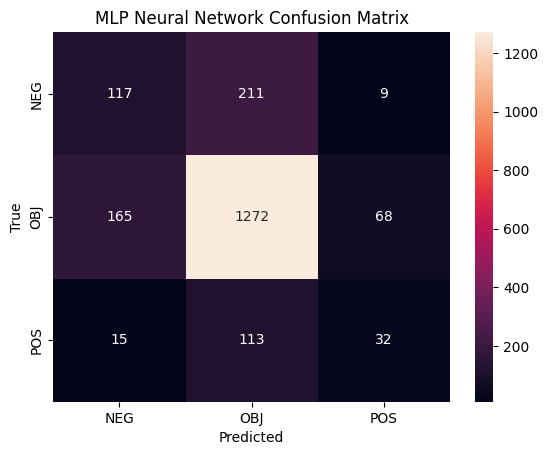

In [26]:
evaluate_model("MLP Neural Network", y_test, y_pred_mlp_test)

### **5.2 Evaluate Random Forest**


=== Random Forest ===
Accuracy: 0.7602397602397603
              precision    recall  f1-score   support

         NEG       0.51      0.28      0.36       337
         OBJ       0.79      0.95      0.86      1505
         POS       0.50      0.01      0.02       160

    accuracy                           0.76      2002
   macro avg       0.60      0.41      0.42      2002
weighted avg       0.72      0.76      0.71      2002



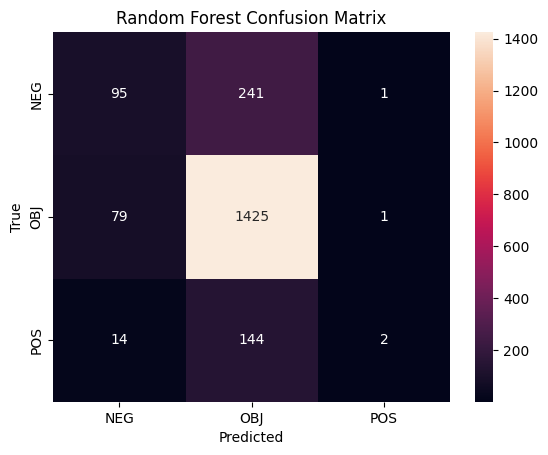

In [27]:
evaluate_model("Random Forest", y_test, y_pred_rf_test)

### **5.3 Evaluate Naïve Bayes**


=== Naïve Bayes ===
Accuracy: 0.7252747252747253
              precision    recall  f1-score   support

         NEG       0.42      0.24      0.31       337
         OBJ       0.78      0.90      0.83      1505
         POS       0.28      0.12      0.17       160

    accuracy                           0.73      2002
   macro avg       0.49      0.42      0.44      2002
weighted avg       0.68      0.73      0.69      2002



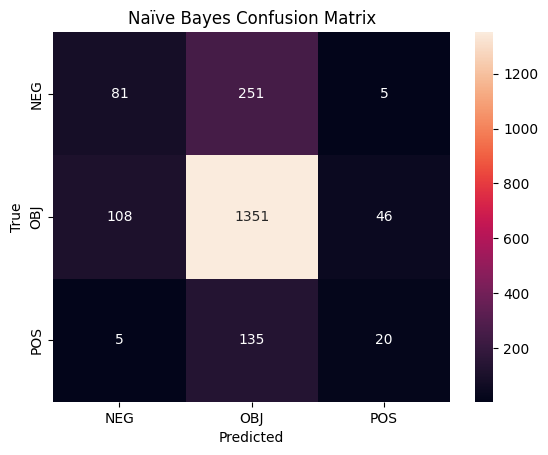

In [28]:
evaluate_model("Naïve Bayes", y_nb_test, y_pred_nb_test)

### **5.4 Evaluate Neural Network**


=== MLP Neural Network ===
Accuracy: 0.7097902097902098
              precision    recall  f1-score   support

         NEG       0.39      0.35      0.37       337
         OBJ       0.80      0.85      0.82      1505
         POS       0.29      0.20      0.24       160

    accuracy                           0.71      2002
   macro avg       0.49      0.46      0.48      2002
weighted avg       0.69      0.71      0.70      2002



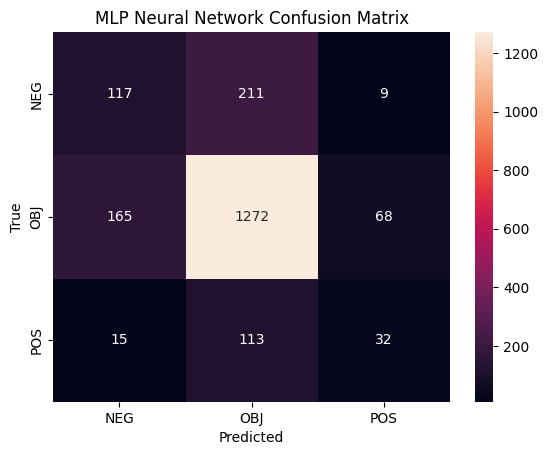

In [29]:
evaluate_model("MLP Neural Network", y_test, y_pred_mlp_test)

In [30]:
results = []

# Add each model
models = {
    "Baseline": y_pred_baseline,
    "Decision Tree": y_pred_dt_test,
    "Random Forest": y_pred_rf_test,
    "Naïve Bayes": y_pred_nb_test,
    "MLP Neural Network": y_pred_mlp_test
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Macro F1": round(f1_macro, 3)
    })

# Create DataFrame
df_results = pd.DataFrame(results)

# Display nicely
print(df_results)


                Model  Accuracy  Macro F1
0            Baseline     0.752     0.286
1       Decision Tree     0.541     0.387
2       Random Forest     0.760     0.415
3         Naïve Bayes     0.725     0.437
4  MLP Neural Network     0.710     0.476
